In [4]:
# ============================================================
# SALARY DISTRIBUTION ANALYSIS
# End-to-End Data Analyst Project
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [5]:
# ============================================================
# 2. LOAD DATASET
# ============================================================

file_path = "C:\\Users\\veerp\\OneDrive\\Desktop\\Full Project DA\\notebooks\\Salary Data.csv"

df_raw = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print(f"Rows    : {df_raw.shape[0]}")
print(f"Columns : {df_raw.shape[1]}")

Dataset loaded successfully.
Rows    : 375
Columns : 6


In [6]:
# ============================================================
# 3. INITIAL DATA INSPECTION
# ============================================================

print("First 5 rows:")
display(df_raw.head())

print("\nDataset Shape:")
print(df_raw.shape)

print("\nDataset Information:")
df_raw.info()

First 5 rows:


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0



Dataset Shape:
(375, 6)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    str    
 2   Education Level      373 non-null    str    
 3   Job Title            373 non-null    str    
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), str(3)
memory usage: 17.7 KB


In [7]:
# ============================================================
# 4. CREATE WORKING COPY
# ============================================================

# Keep the original dataset untouched
df = df_raw.copy()

print(f"Working dataset shape: {df.shape}")

Working dataset shape: (375, 6)


In [8]:
# ============================================================
# 5. CHECK MISSING VALUES
# ============================================================

print("Missing values before cleaning:")
print(df.isnull().sum())

print("\nMissing value percentage:")
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage.round(2))

Missing values before cleaning:
Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

Missing value percentage:
Age                    0.53
Gender                 0.53
Education Level        0.53
Job Title              0.53
Years of Experience    0.53
Salary                 0.53
dtype: float64


In [9]:
# ============================================================
# 6. REMOVE ONLY COMPLETELY EMPTY ROWS
# ============================================================

# IMPORTANT:
# how='all' removes a row only when ALL columns are missing.
# We do NOT use df.dropna() because that would remove
# partially incomplete employee records.

before_rows = len(df)

df = df.dropna(how='all')

after_rows = len(df)

print(f"Rows before removing completely empty rows : {before_rows}")
print(f"Rows after removing completely empty rows  : {after_rows}")
print(f"Rows removed                              : {before_rows - after_rows}")

Rows before removing completely empty rows : 375
Rows after removing completely empty rows  : 373
Rows removed                              : 2


In [10]:
# ============================================================
# 7. CHECK REMAINING MISSING VALUES
# ============================================================

print("Remaining missing values:")
print(df.isnull().sum())

print("\nRows containing missing values:")
display(df[df.isnull().any(axis=1)])

Remaining missing values:
Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

Rows containing missing values:


,Age,Gender,Education Level,Job Title,Years of Experience,Salary


In [11]:
# ============================================================
# 8. CHECK DUPLICATE RECORDS
# ============================================================

duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count}")

Duplicate rows: 49


In [12]:
# ============================================================
# 9. DISPLAY DUPLICATE RECORDS
# ============================================================

if duplicate_count > 0:
    display(df[df.duplicated(keep=False)])
else:
    print("No duplicate records found.")

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
140,28.0,Male,Bachelor's,Junior Business Analyst,2.0,40000.0
195,28.0,Male,Bachelor's,Junior Business Analyst,2.0,40000.0
209,30.0,Female,Bachelor's,Junior Marketing Coordinator,2.0,40000.0
210,38.0,Male,Master's,Senior IT Consultant,9.0,110000.0
211,45.0,Female,PhD,Senior Product Designer,15.0,150000.0
212,28.0,Male,Bachelor's,Junior Business Development Associate,2.0,40000.0
213,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0
214,44.0,Male,Bachelor's,Senior Software Engineer,14.0,130000.0
215,34.0,Female,Master's,Senior Financial Advisor,6.0,100000.0
216,35.0,Male,Bachelor's,Senior Project Coordinator,9.0,95000.0


In [13]:
# ============================================================
# 10. REMOVE DUPLICATES
# ============================================================

before_duplicates = len(df)

df = df.drop_duplicates()

after_duplicates = len(df)

print(f"Rows before duplicate removal : {before_duplicates}")
print(f"Rows after duplicate removal  : {after_duplicates}")
print(f"Duplicates removed            : {before_duplicates - after_duplicates}")

Rows before duplicate removal : 373
Rows after duplicate removal  : 324
Duplicates removed            : 49


In [14]:
# ============================================================
# 11. CHECK DATA TYPES
# ============================================================

print(df.dtypes)

Age                    float64
Gender                     str
Education Level            str
Job Title                  str
Years of Experience    float64
Salary                 float64
dtype: object


In [15]:
# ============================================================
# 12. CLEAN TEXT COLUMNS
# ============================================================

categorical_columns = [
    'Gender',
    'Education Level',
    'Job Title'
]

for col in categorical_columns:
    df[col] = df[col].str.strip()

print("Text columns cleaned.")

Text columns cleaned.


In [16]:
# ============================================================
# 13. CHECK CATEGORICAL VALUES
# ============================================================

print("Gender:")
print(df['Gender'].value_counts(dropna=False))

print("\nEducation Level:")
print(df['Education Level'].value_counts(dropna=False))

print("\nNumber of unique Job Titles:")
print(df['Job Title'].nunique())

Gender:
Gender
Male      170
Female    154
Name: count, dtype: int64

Education Level:
Education Level
Bachelor's    191
Master's       91
PhD            42
Name: count, dtype: int64

Number of unique Job Titles:
174


In [17]:
# ============================================================
# 14. DISPLAY ALL JOB TITLES
# ============================================================

job_titles = sorted(df['Job Title'].dropna().unique())

for title in job_titles:
    print(title)

Account Manager
Accountant
Administrative Assistant
Business Analyst
Business Development Manager
Business Intelligence Analyst
CEO
Chief Data Officer
Chief Technology Officer
Content Marketing Manager
Copywriter
Creative Director
Customer Service Manager
Customer Service Rep
Customer Service Representative
Customer Success Manager
Customer Success Rep
Data Analyst
Data Entry Clerk
Data Scientist
Digital Content Producer
Digital Marketing Manager
Director
Director of Business Development
Director of Engineering
Director of Finance
Director of HR
Director of Human Capital
Director of Human Resources
Director of Marketing
Director of Operations
Director of Product Management
Director of Sales
Director of Sales and Marketing
Event Coordinator
Financial Advisor
Financial Analyst
Financial Manager
Graphic Designer
HR Generalist
HR Manager
Help Desk Analyst
Human Resources Director
IT Manager
IT Support
IT Support Specialist
Junior Account Manager
Junior Accountant
Junior Advertising Coordin

In [18]:
# ============================================================
# 15. NUMERICAL DATA SUMMARY
# ============================================================

numeric_columns = [
    'Age',
    'Years of Experience',
    'Salary'
]

display(df[numeric_columns].describe())

,Age,Years of Experience,Salary
count,324.000000,324.000000,324.000000
mean,37.382716,10.058642,99985.648148
std,7.185844,6.650470,48652.271440
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.500000,9.000000,95000.000000
75%,44.000000,16.000000,140000.000000
max,53.000000,25.000000,250000.000000


In [19]:
# ============================================================
# 16. CHECK INVALID AGE VALUES
# ============================================================

invalid_age = df[df['Age'] < 18]

print(f"Records with Age < 18: {len(invalid_age)}")

if len(invalid_age) > 0:
    display(invalid_age)

Records with Age < 18: 0


In [20]:
# ============================================================
# 17. CHECK INVALID EXPERIENCE VALUES
# ============================================================

invalid_experience = df[df['Years of Experience'] < 0]

print(f"Records with negative experience: {len(invalid_experience)}")

if len(invalid_experience) > 0:
    display(invalid_experience)

Records with negative experience: 0


In [21]:
# ============================================================
# 18. CHECK INVALID SALARY VALUES
# ============================================================

invalid_salary = df[df['Salary'] <= 0]

print(f"Records with Salary <= 0: {len(invalid_salary)}")

if len(invalid_salary) > 0:
    display(invalid_salary)

Records with Salary <= 0: 0


In [22]:
# ============================================================
# 19. CHECK EXPERIENCE > AGE
# ============================================================

invalid_age_experience = df[
    df['Years of Experience'] > df['Age']
]

print(
    f"Records where experience is greater than age: "
    f"{len(invalid_age_experience)}"
)

if len(invalid_age_experience) > 0:
    display(invalid_age_experience)

Records where experience is greater than age: 0


In [23]:
# ============================================================
# 20. SALARY OUTLIER DETECTION USING IQR
# ============================================================

Q1 = df['Salary'].quantile(0.25)
Q3 = df['Salary'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

print(f"Q1             : {Q1:,.2f}")
print(f"Q3             : {Q3:,.2f}")
print(f"IQR            : {IQR:,.2f}")
print(f"Lower Bound    : {lower_bound:,.2f}")
print(f"Upper Bound    : {upper_bound:,.2f}")

Q1             : 55,000.00
Q3             : 140,000.00
IQR            : 85,000.00
Lower Bound    : -72,500.00
Upper Bound    : 267,500.00


In [24]:
# ============================================================
# 21. IDENTIFY SALARY OUTLIERS
# ============================================================

salary_outliers = df[
    (df['Salary'] < lower_bound) |
    (df['Salary'] > upper_bound)
]

print(f"Number of salary outliers: {len(salary_outliers)}")

if len(salary_outliers) > 0:
    display(
        salary_outliers[
            [
                'Job Title',
                'Education Level',
                'Years of Experience',
                'Salary'
            ]
        ].sort_values('Salary', ascending=False)
    )

Number of salary outliers: 0


In [25]:
# ============================================================
# 22. SALARY MEAN VS MEDIAN
# ============================================================

mean_salary = df['Salary'].mean()
median_salary = df['Salary'].median()

print(f"Mean Salary   : {mean_salary:,.2f}")
print(f"Median Salary : {median_salary:,.2f}")

Mean Salary   : 99,985.65
Median Salary : 95,000.00


In [26]:
# ============================================================
# 23. FINAL DATA QUALITY SUMMARY
# ============================================================

print("FINAL DATA QUALITY CHECK")
print("=" * 50)

print(f"Rows                  : {len(df)}")
print(f"Columns               : {df.shape[1]}")
print(f"Duplicate rows        : {df.duplicated().sum()}")
print(f"Total missing values  : {df.isnull().sum().sum()}")
print(f"Salary outliers       : {len(salary_outliers)}")

FINAL DATA QUALITY CHECK
Rows                  : 324
Columns               : 6
Duplicate rows        : 0
Total missing values  : 0
Salary outliers       : 0


In [27]:
# ============================================================
# 24. CREATE CLEAN DATASET
# ============================================================

df_clean = df.copy()

print("Clean dataset created.")
print(f"Final shape: {df_clean.shape}")

Clean dataset created.
Final shape: (324, 6)


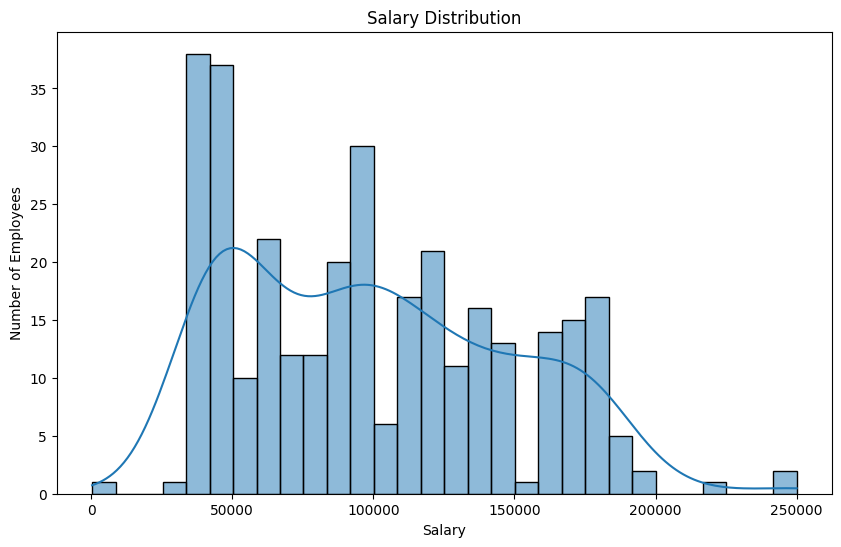

In [28]:
#EDA
# ============================================================
# 25. SALARY DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_clean,
    x='Salary',
    bins=30,
    kde=True
)

plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Number of Employees')

plt.show()

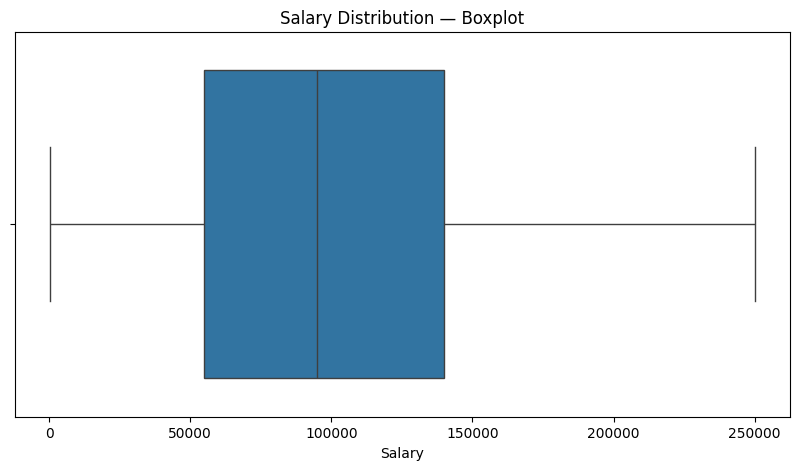

In [30]:
# ============================================================
# 26. SALARY BOXPLOT
# ============================================================

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df_clean,
    x='Salary'
)

plt.title('Salary Distribution — Boxplot')
plt.xlabel('Salary')

plt.show()

In [31]:
# ============================================================
# 27. SALARY BY GENDER
# ============================================================

gender_salary = (
    df_clean
    .groupby('Gender')['Salary']
    .agg(['count', 'mean', 'median'])
    .sort_values('mean', ascending=False)
)

display(gender_salary)

,count,mean,median
Gender,,,
Male,170,103472.647059,97500.0
Female,154,96136.363636,90000.0


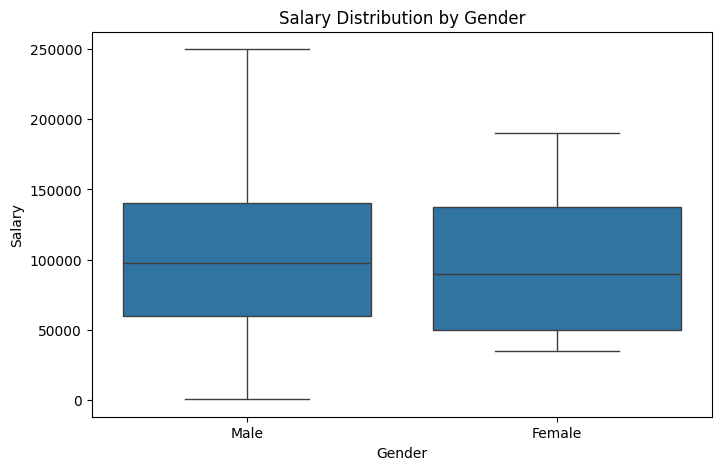

In [32]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x='Gender',
    y='Salary'
)

plt.title('Salary Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Salary')

plt.show()

In [33]:
# ============================================================
# 28. SALARY BY EDUCATION LEVEL
# ============================================================

education_salary = (
    df_clean
    .groupby('Education Level')['Salary']
    .agg(['count', 'mean', 'median'])
    .sort_values('mean', ascending=False)
)

display(education_salary)

,count,mean,median
Education Level,,,
PhD,42,158095.238095,157500.0
Master's,91,127912.087912,120000.0
Bachelor's,191,73902.356021,60000.0


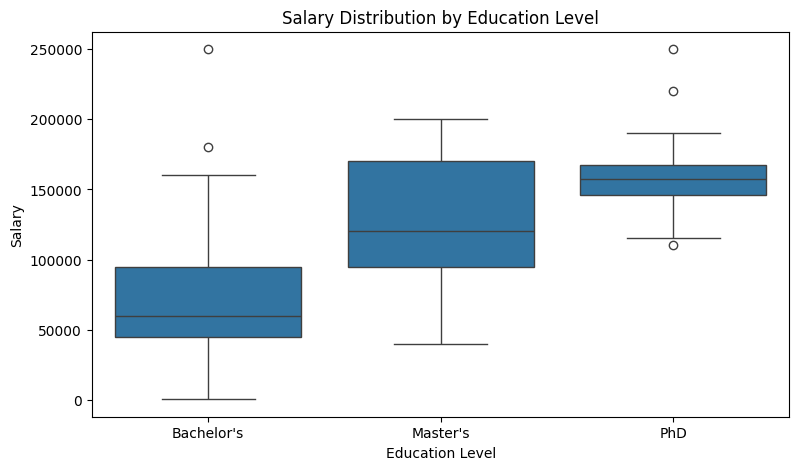

In [34]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df_clean,
    x='Education Level',
    y='Salary'
)

plt.title('Salary Distribution by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Salary')

plt.show()

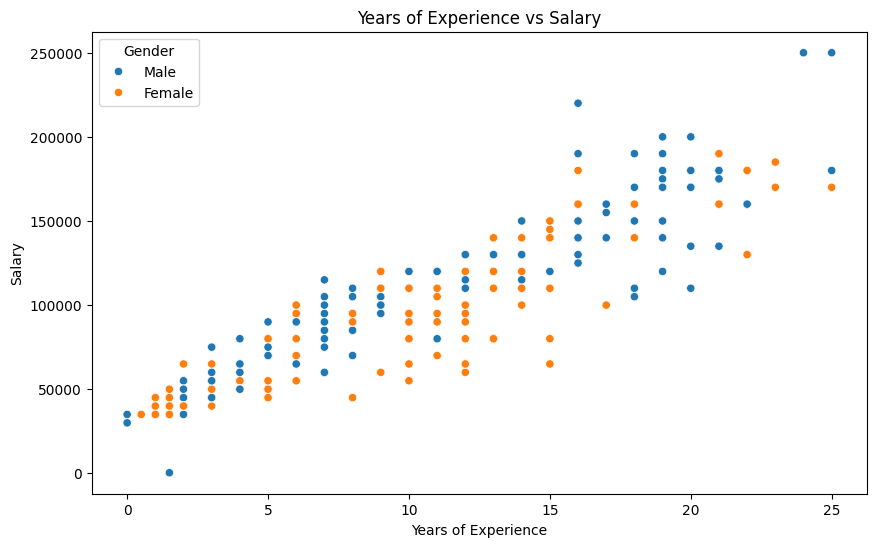

In [35]:
# ============================================================
# 29. EXPERIENCE VS SALARY
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x='Years of Experience',
    y='Salary',
    hue='Gender'
)

plt.title('Years of Experience vs Salary')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')

plt.show()

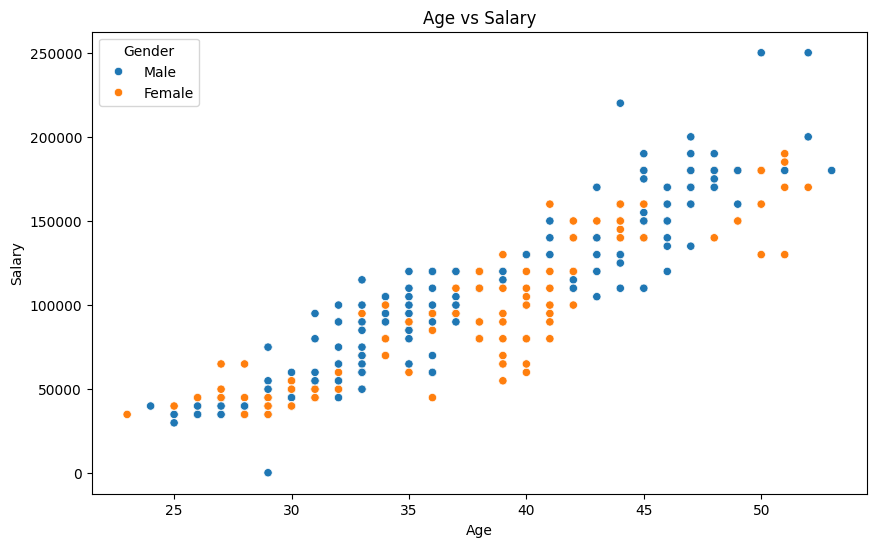

In [36]:
# ============================================================
# 30. AGE VS SALARY
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x='Age',
    y='Salary',
    hue='Gender'
)

plt.title('Age vs Salary')
plt.xlabel('Age')
plt.ylabel('Salary')

plt.show()

In [37]:
# ============================================================
# 31. TOP 15 HIGHEST-PAYING JOB TITLES
# ============================================================

top_jobs = (
    df_clean
    .groupby('Job Title')['Salary']
    .agg(['count', 'mean', 'median'])
    .query('count >= 2')
    .sort_values('mean', ascending=False)
    .head(15)
)

display(top_jobs)

,count,mean,median
Job Title,,,
Director of Human Resources,2,187500.000000,187500.0
Director of Engineering,2,180000.000000,180000.0
Director of Marketing,8,176250.000000,180000.0
Director of Finance,2,175000.000000,175000.0
Director of Operations,9,172222.222222,170000.0
Senior Data Scientist,6,160000.000000,160000.0
Senior Manager,2,160000.000000,160000.0
Senior Data Analyst,3,155000.000000,155000.0
Senior Data Engineer,2,155000.000000,155000.0


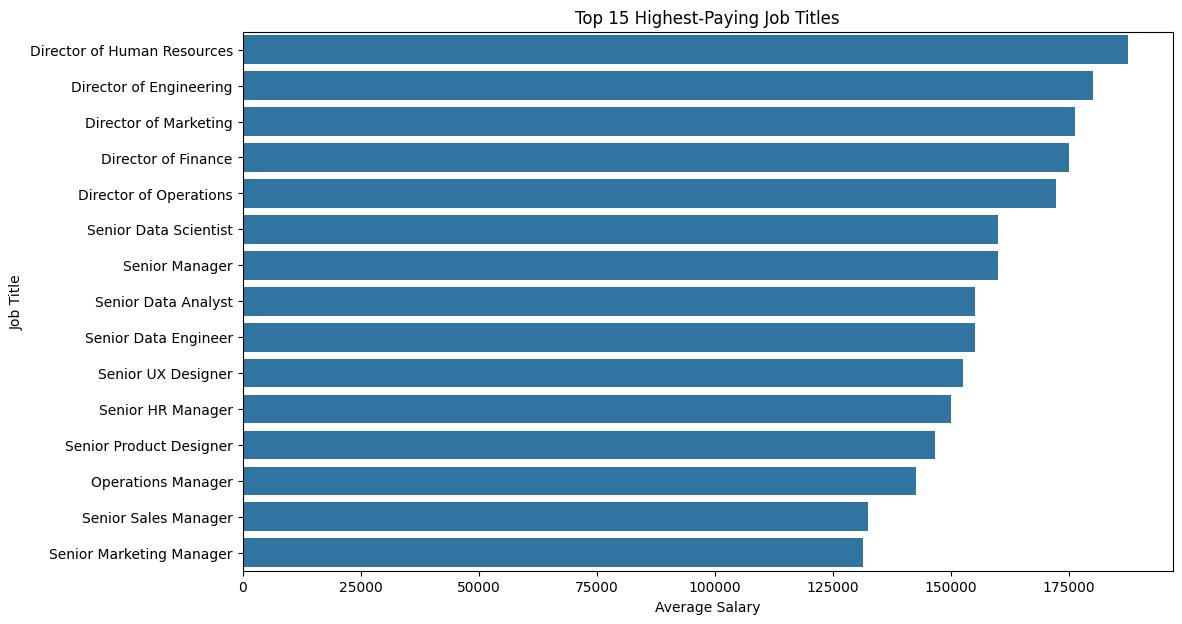

In [38]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_jobs.reset_index(),
    x='mean',
    y='Job Title'
)

plt.title('Top 15 Highest-Paying Job Titles')
plt.xlabel('Average Salary')
plt.ylabel('Job Title')

plt.show()

In [39]:
# ============================================================
# 32. CORRELATION MATRIX
# ============================================================

correlation = df_clean[
    ['Age', 'Years of Experience', 'Salary']
].corr()

display(correlation)

,Age,Years of Experience,Salary
Age,1.000000,0.979192,0.916543
Years of Experience,0.979192,1.000000,0.924455
Salary,0.916543,0.924455,1.000000


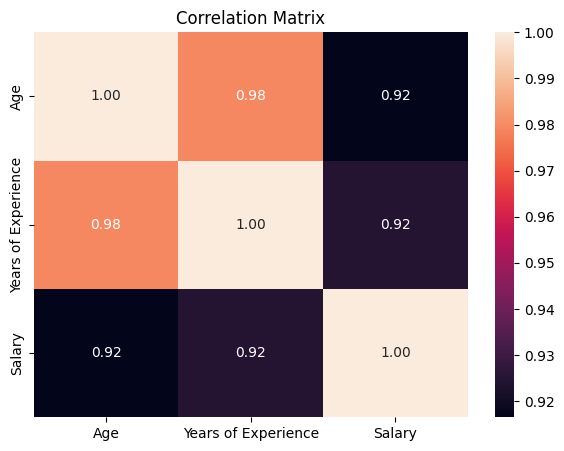

In [40]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f'
)

plt.title('Correlation Matrix')

plt.show()

In [41]:
# ============================================================
# 33. EXPORT CLEAN DATASET
# ============================================================

df_clean.to_csv(
    'salary_data_cleaned.csv',
    index=False
)

print("Clean dataset saved as salary_data_cleaned.csv")

Clean dataset saved as salary_data_cleaned.csv


In [42]:
df.isnull().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

In [43]:
df[df.isnull().any(axis=1)]

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
